In [62]:
# Install requirements
%pip install kaggle
%pip install shap
%pip install groq
%pip install pandas
%pip install scikit-learn
%pip install xgboost
%pip install matplotlib
%pip install seaborn


In [63]:
from google.colab import userdata
import os

# Obtener token desde secretos
KAGGLE_API_TOKEN = userdata.get('KAGGLE_API_TOKEN')

# Crear carpeta .kaggle
os.makedirs('/root/.kaggle', exist_ok=True)

# Guardar token en access_token
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_API_TOKEN)

# Permisos requeridos
os.chmod('/root/.kaggle/access_token', 0o600)

print("Kaggle token configurado correctamente.")

Kaggle token configurado correctamente.


#### **Descarga y Descompresión del Dataset de Kaggle**

Para asegurar la reproducibilidad del notebook, se descargará el dataset `kube-ids0` directamente desde Kaggle y se descomprimirá en el entorno de Colab.

In [64]:
# Descargar el dataset de Kaggle
!kaggle datasets download -d redamorsli/kube-ids0

# Descomprimir el archivo zip
import zipfile
import os

zip_file_name = 'kube-ids0.zip'
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"Dataset '{zip_file_name}' descomprimido en /content/.")
else:
    print(f"El archivo '{zip_file_name}' no se encontró. Asegúrate de que la descarga fue exitosa.")

Dataset URL: https://www.kaggle.com/datasets/redamorsli/kube-ids0
License(s): unknown
kube-ids0.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset 'kube-ids0.zip' descomprimido en /content/.


In [65]:
import pandas as pd

# Define the file path for the dataset
file_path = '/content/boa_dataset/processed/boa_dataset_ml_ready_frontend_microservice.csv'

# Load the CSV file into a pandas DataFrame, ensuring original labels are intact
df = pd.read_csv(file_path)


### **SECCIÓN 2.1: Descripción del dataset**

* **Numero de registros:** 10069
* **Features:** 225 numéricas
* **Variable objetivo:** Label, **tipo:** Multiclase
* **Tamaño:** 14.030KB

### **SECCIÓN 2.2: Hallazgos del análisis exploratorio:**

**1. Distribución de la variable objetivo (`label`):**

*   **Desbalance**: El gráfico de barras de la distribución de `label` muestra un desbalance ya que el número de registros 'Normal' (label 0) es significativamente mayor que el de los ataques (labels 1 y 2). Este desbalance es crucial considerarlo en el entrenamiento del modelo, ya que puede llevar a que el modelo sea sesgado hacia la clase mayoritaria.

/tmp/ipykernel_2391/3364820860.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


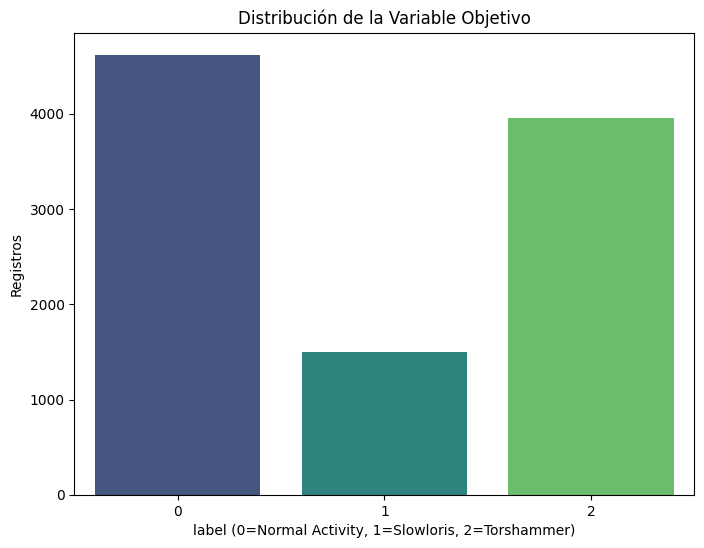

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo')
plt.xlabel('label (0=Normal Activity, 1=Slowloris, 2=Torshammer)')
plt.ylabel('Registros')
plt.show()


**Outliers**: En la distribución de las características seleccionadas,
los boxplots permitieron identificar patrones relevantes:

* Torshammer (label 2) presentó distribuciones altamente
uniformes con respecto a las tres características, algo
que no ocurre en Normal Activity ni en Slowloris.

* Slowloris (label 1) no tiene un patrón claro para estas características, o los pocos registros no permiten observar
su comportamiento.

* Normal Activity (label 0) es el único que presenta alta
variabilidad y valores atípicos en ambas direcciones,
reflejando la dinámica real de un clúster Kubernetes.

* La variable container_memory_usage_bytes presenta
un comportamiento muy similar entre las tres clases del
label, diferenciándose únicamente por algunos valores
atípicos asociados a Normal Activity (label 0).

Debido
a esta baja capacidad de separación entre clases, esta
característica no resulta especialmente discriminativa
para el proceso de clasificación

/tmp/ipykernel_2391/2624911761.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='plasma')


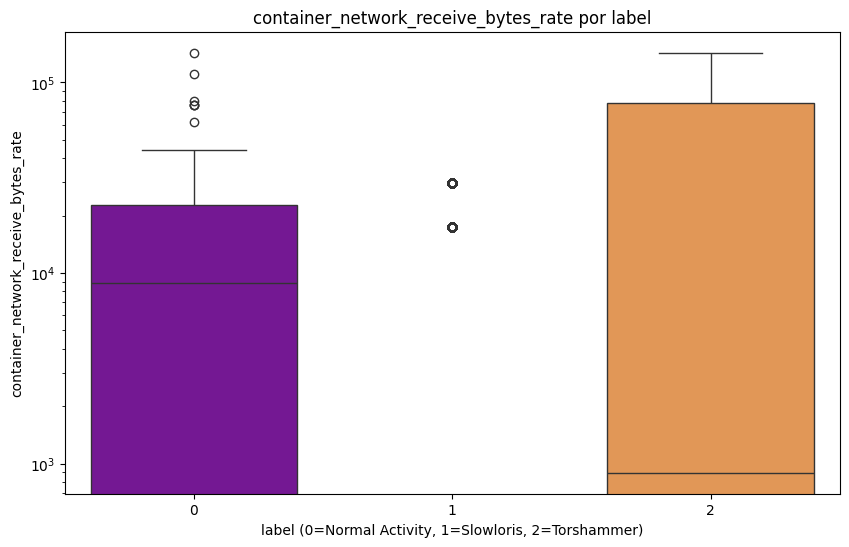

/tmp/ipykernel_2391/2624911761.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='plasma')


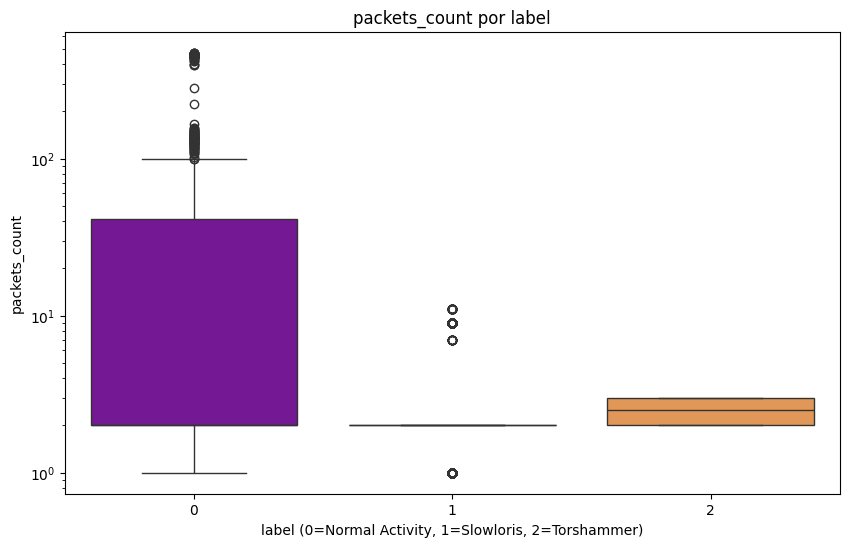

/tmp/ipykernel_2391/2624911761.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='plasma')


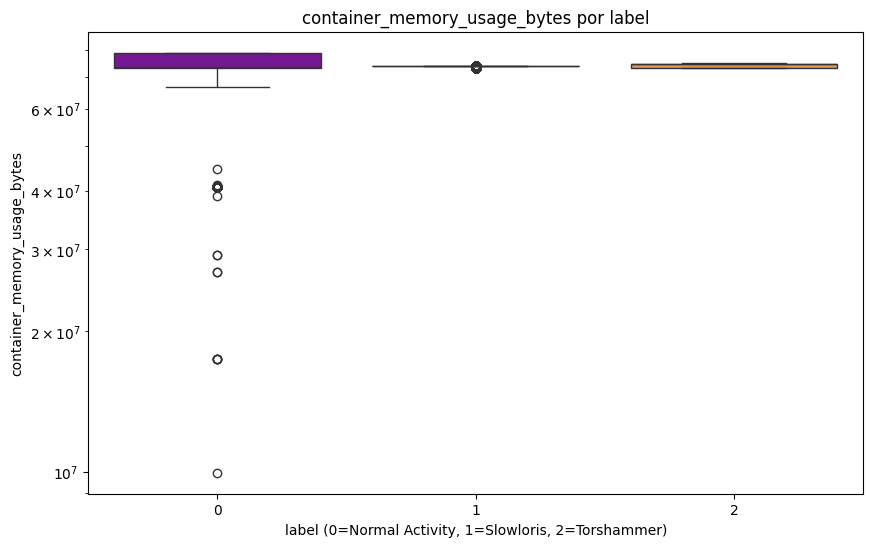

In [67]:
features_to_boxplot = [
    'container_network_receive_bytes_rate',
    'packets_count',
    'container_memory_usage_bytes'
]

for feature in features_to_boxplot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='label', y=feature, data=df, palette='plasma')
    plt.title(f'{feature} por label')
    plt.xlabel('label (0=Normal Activity, 1=Slowloris, 2=Torshammer)')
    plt.ylabel(feature)
    plt.yscale('log') # Usar escala logarítmica para mejor visualización si hay grandes variaciones
    plt.show()


**2. Valores nulos y estrategia de imputación aplicada:**

Al ejecutar el código para `df.isnull().sum()`, podremos ver que no hay columnas con valores nulos.



In [68]:
print("Valores nulos por columna:")
null_counts = df.isnull().sum()
# Filtrar y mostrar solo las columnas con valores nulos
null_columns = null_counts[null_counts > 0]
if not null_columns.empty:
    display(null_columns.sort_values(ascending=False))
else:
    print("No hay valores nulos en el DataFrame.")


Valores nulos por columna:
No hay valores nulos en el DataFrame.


**3. Variables con mayor correlación con el target (`label`):**

El análisis de correlación con la columna `label` revela que las características total_payload_bytes, container_network_receive_packets_rate,
y container_sockets muestran mayor discrepancia entre las tres clases:

Estas diferencias tan marcadas reflejan la naturaleza intrínseca de cada comportamiento.
En un clúster normal,
las aplicaciones intercambian datos reales (payload alto),
generan tráfico de red moderado y variable, y mantienen
un número significativo de sockets por la operación legítima de múltiples servicios.

Slowloris envía cabeceras HTTP
incompletas de forma muy lenta y con payload mínimo
(44 bytes por conexión), no recibe respuesta significativa,
abre pocos sockets para no saturarse localmente y su tasa
de paquetes es baja.

Torshammer, en cambio, utiliza conexiones HTTP completas pero repetitivas sin payload,
genera una tasa altísima de paquetes por segundo (510)
para abrumar el objetivo, y abre muchos sockets (515) para
mantener múltiples conexiones paralelas.

Así, los valores
extremos de Torshammer revelan su naturaleza agresiva
y volumétrica, mientras que los valores intermedios pero
muy bajos de Slowloris evidencian su estrategia de "bajo
y lento"para evadir detección.

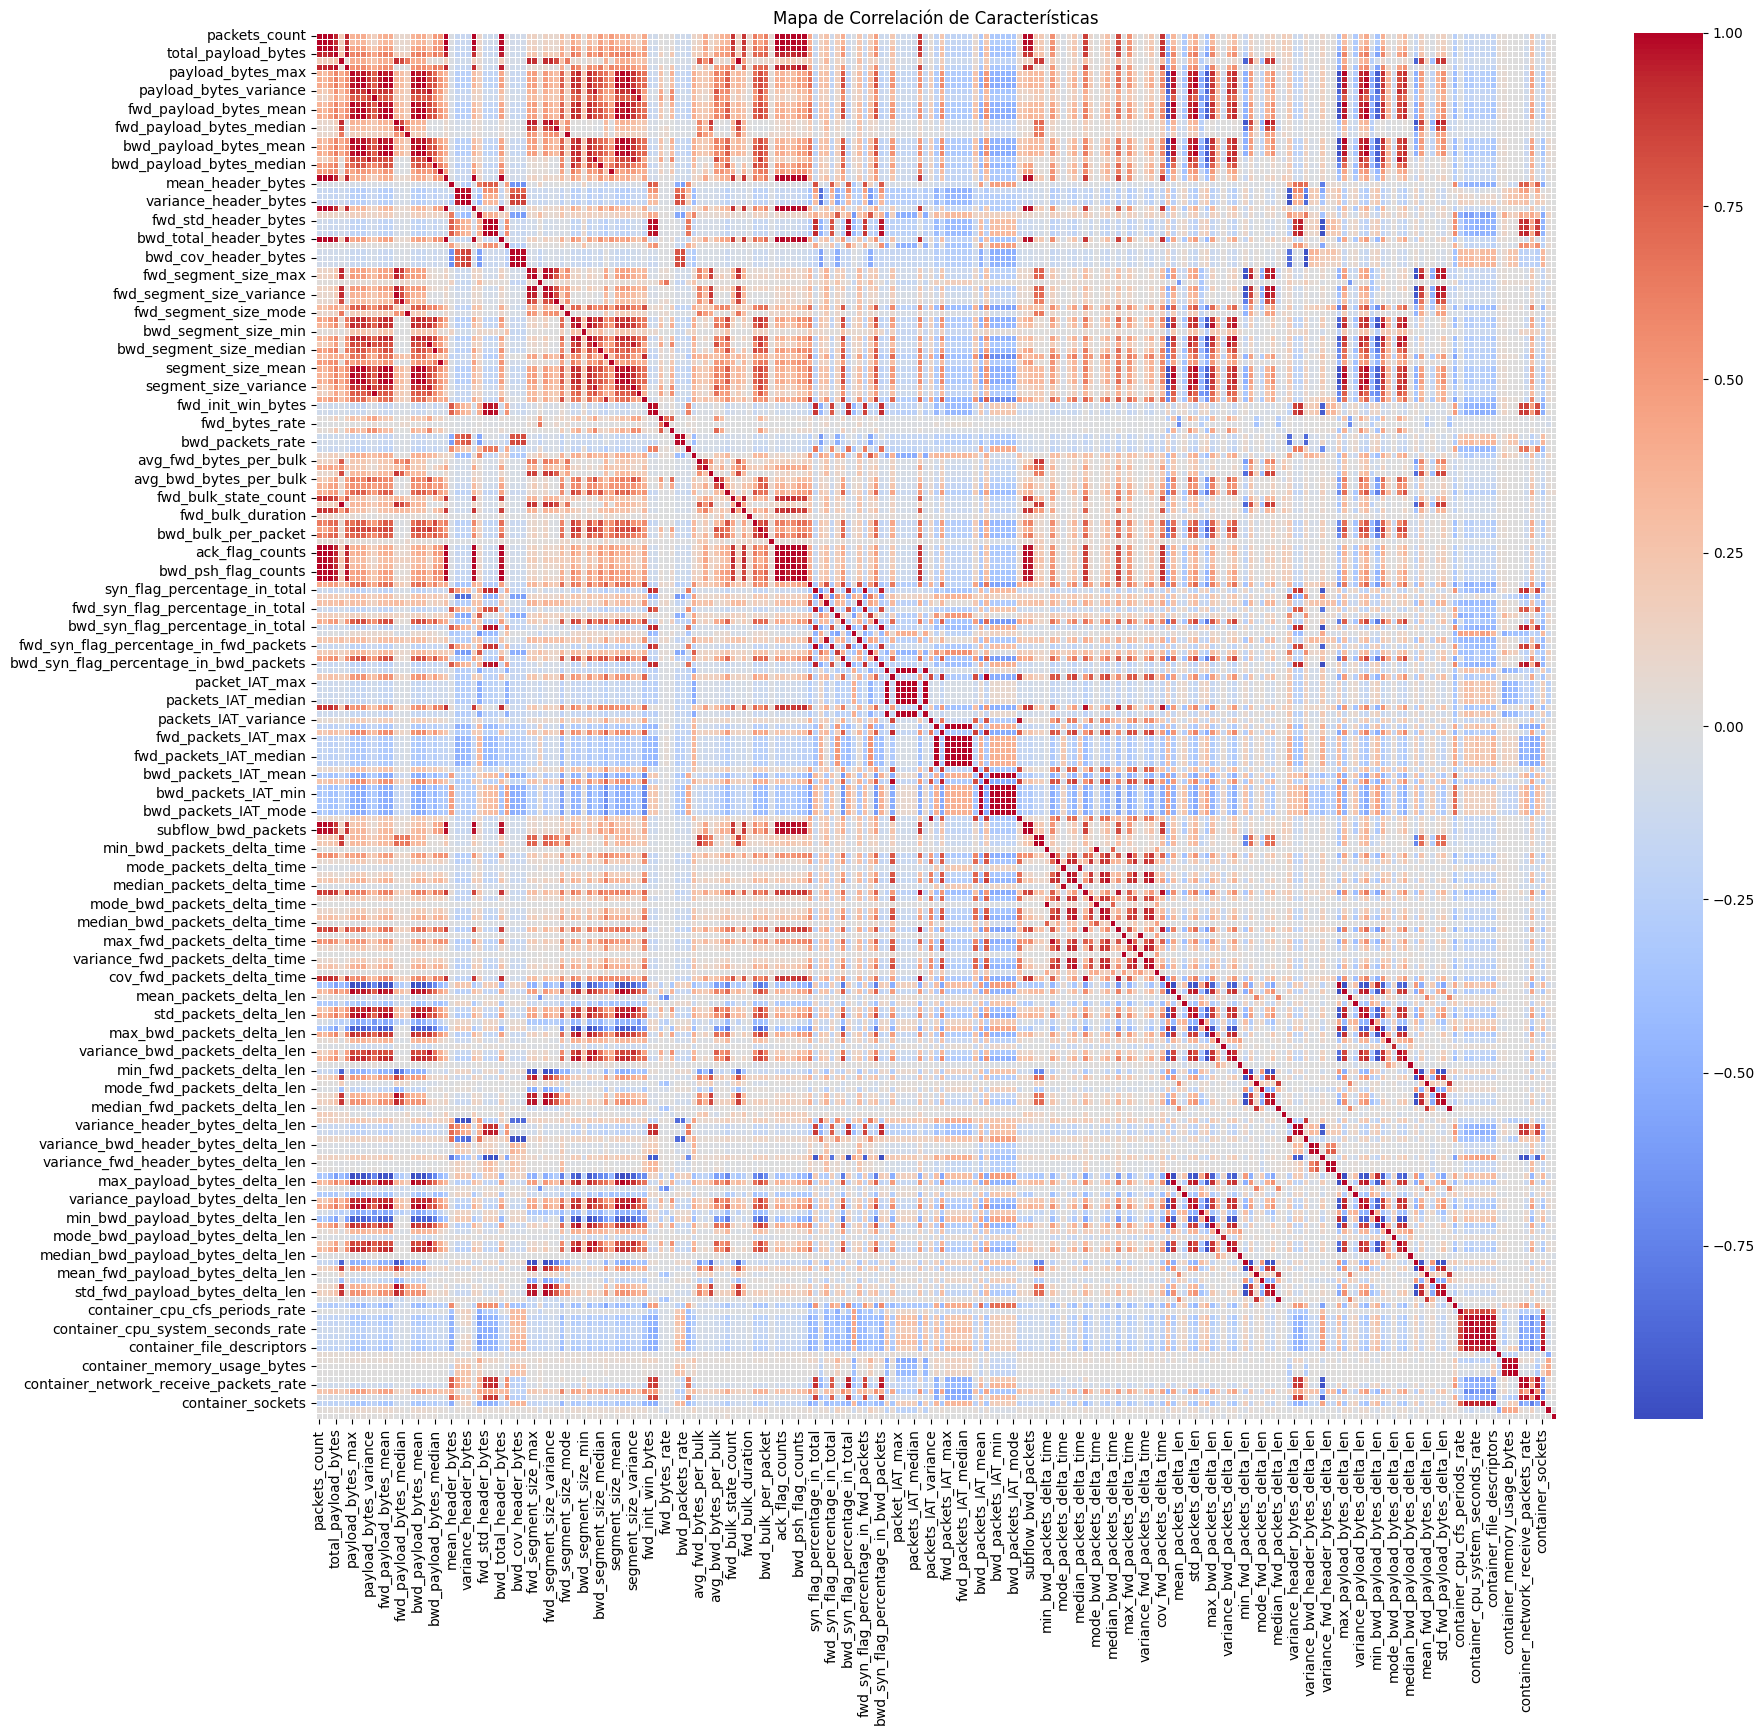

In [69]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Correlación de Características')
plt.show()


### **Correlaciones con la variable `label`**


In [70]:
correlations_with_label = df.corr(numeric_only=True)['label'].sort_values(ascending=False)
print("Características más correlacionadas con 'label':\n")
display(correlations_with_label)


Características más correlacionadas con 'label':



,label
label,1.000000
bwd_packets_IAT_min,0.688049
bwd_packets_IAT_mode,0.688049
bwd_packets_IAT_median,0.688049
bwd_packets_IAT_mean,0.688049
...,...
bwd_psh_flag_percentage_in_bwd_packets,-0.527147
psh_flag_percentage_in_total,-0.528221
segment_size_cov,-0.535498
bwd_segment_size_cov,-0.550412


**Promedio de valores agrupados por el Label**

In [71]:
print("Métricas promedio agrupadas por 'label' (0=Normal, 1=Slowloris, 2=Torshammer):")
display(df.groupby('label').mean())

Métricas promedio agrupadas por 'label' (0=Normal, 1=Slowloris, 2=Torshammer):


,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,payload_bytes_mean,payload_bytes_std,payload_bytes_variance,...,container_memory_rss,container_memory_usage_bytes,container_memory_working_set_bytes,container_network_receive_bytes_rate,container_network_receive_packets_rate,container_network_transmit_bytes_rate,container_network_transmit_packets_rate,container_sockets,container_threads,container_last_seen_rate
label,,,,,,,,,,,,,,,,,,,,,
0,32.036789,16.447955,15.588834,52121.914953,6181.262714,45940.65224,3506.697252,753.897789,1087.255584,3.664432e+06,...,6.688372e+07,7.216990e+07,7.216990e+07,12313.944385,65.471529,64038.285276,94.462749,436.698301,6.952287,106.276203
1,3.227273,1.814171,1.413102,44.268717,44.268717,0.00000,37.475267,6.570572,12.418659,5.420947e+02,...,7.025867e+07,7.387691e+07,7.387691e+07,4709.991599,21.740437,30195.722039,28.380587,138.284091,7.000000,1.237299
2,2.500000,1.500000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00,...,7.040424e+07,7.419309e+07,7.419309e+07,39281.676604,510.255208,46354.419998,274.082778,515.778087,7.000000,0.699646


## **SECCIÓN 3:**
### **SECCIÓN 3.1: Componentes principales**

#### **Preprocesamiento de Datos**

El preprocesamiento de datos es un paso fundamental para preparar el dataset antes de entrenar cualquier modelo de Machine Learning. Incluye tareas como la selección de características y el escalado de datos, entre otras, para mejorar el rendimiento del modelo.

##### **3.1.1 Selección de Características (Feature Selection)**

Dado el gran número de características (225), es vital realizar una selección para evitar la 'maldición de la dimensionalidad', reducir el ruido y mejorar la interpretabilidad y el rendimiento del modelo. Utilizaremos la correlación de cada característica con la variable objetivo `label` para quedarnos solo con aquellas que muestren una relación significativa (por ejemplo, un valor absoluto de correlación mayor a 0.1).

In [72]:
correlation_threshold = 0.1

# Filtrar características basándose en el valor absoluto de la correlación
# con 'label', excluyendo la propia 'label'
relevant_features = correlations_with_label[abs(correlations_with_label) > correlation_threshold].index.tolist()

if 'label' in relevant_features:
    relevant_features.remove('label')

# Crear un nuevo DataFrame con solo las características seleccionadas y la variable objetivo
X = df[relevant_features]  # Características
y = df['label']             # Variable objetivo

print(f"Número total de características originales: {df.shape[1] - 1}") # Restamos 1 por la columna 'label'
print(f"Número de características seleccionadas (correlación > {correlation_threshold}): {len(relevant_features)}")
print("Primeras 5 características seleccionadas:", relevant_features[:5])

# Mostrar las primeras filas del nuevo DataFrame de características
print("\nPrimeras 5 filas del DataFrame de características (X):")
display(X.head())


Número total de características originales: 224
Número de características seleccionadas (correlación > 0.1): 177
Primeras 5 características seleccionadas: ['bwd_packets_IAT_min', 'bwd_packets_IAT_mode', 'bwd_packets_IAT_median', 'bwd_packets_IAT_mean', 'bwd_packets_IAT_max']

Primeras 5 filas del DataFrame de características (X):


,bwd_packets_IAT_min,bwd_packets_IAT_mode,bwd_packets_IAT_median,bwd_packets_IAT_mean,bwd_packets_IAT_max,bwd_packets_IAT_total,bwd_syn_flag_percentage_in_bwd_packets,mean_header_bytes,bwd_syn_flag_percentage_in_total,fwd_variance_header_bytes,...,cov_bwd_packets_delta_time,std_packets_delta_len,std_payload_bytes_delta_len,bwd_ack_flag_percentage_in_total,bwd_psh_flag_percentage_in_total,bwd_psh_flag_percentage_in_bwd_packets,psh_flag_percentage_in_total,segment_size_cov,bwd_segment_size_cov,mean_fwd_header_bytes_delta_len
0,0.000033,0.0000,0.0008,0.5056,4.502514,4.550614,0.0,32.0,0.0,0.0,...,2.5587,1391.5764,1391.5764,0.526316,0.421053,0.800000,0.631579,1.8525,1.3855,0.0
1,0.000099,0.0001,0.0001,0.0001,0.000099,0.000099,0.0,32.0,0.0,0.0,...,0.0000,2188.1394,2188.1394,0.500000,0.250000,0.500000,0.500000,1.6631,0.4286,0.0
2,0.000021,0.0000,0.0001,0.1598,1.984517,3.994740,0.0,32.0,0.0,0.0,...,3.2606,2597.4367,2597.4367,0.464286,0.357143,0.769231,0.678571,1.5916,0.8537,0.0
3,0.000004,0.0000,0.0001,0.1648,1.047860,4.615520,0.0,32.0,0.0,0.0,...,2.6072,5622.9322,5622.9322,0.604167,0.520833,0.862069,0.666667,1.3882,1.0020,0.0
4,0.000024,0.0000,0.0017,0.5712,1.998348,3.998419,0.0,32.0,0.0,0.0,...,1.5340,1268.8963,1268.8963,0.533333,0.400000,0.750000,0.666667,1.7316,1.1791,0.0


##### **3.1.2. Escalado de Datos (Data Scaling)**

El escalado de datos es crucial para evitar que las características con rangos de valores más grandes dominen sobre aquellas con rangos más pequeños. Utilizaremos `StandardScaler` para transformar las características a una media de 0 y una desviación estándar de 1.

In [73]:
from sklearn.preprocessing import StandardScaler

# Inicializar el StandardScaler
scaler = StandardScaler()

# Escalar las características
X_scaled = scaler.fit_transform(X)

# Convertir el array escalado de nuevo a un DataFrame para facilitar el manejo
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Características escaladas. Primeras 5 filas del DataFrame escalado (X_scaled_df):")
display(X_scaled_df.head())


Características escaladas. Primeras 5 filas del DataFrame escalado (X_scaled_df):


,bwd_packets_IAT_min,bwd_packets_IAT_mode,bwd_packets_IAT_median,bwd_packets_IAT_mean,bwd_packets_IAT_max,bwd_packets_IAT_total,bwd_syn_flag_percentage_in_bwd_packets,mean_header_bytes,bwd_syn_flag_percentage_in_total,fwd_variance_header_bytes,...,cov_bwd_packets_delta_time,std_packets_delta_len,std_payload_bytes_delta_len,bwd_ack_flag_percentage_in_total,bwd_psh_flag_percentage_in_total,bwd_psh_flag_percentage_in_bwd_packets,psh_flag_percentage_in_total,segment_size_cov,bwd_segment_size_cov,mean_fwd_header_bytes_delta_len
0,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-0.518763,-0.165885,-0.524728,-0.546131,...,1.257048,0.341529,0.341912,0.126911,1.893811,1.954048,1.626650,2.363663,2.589157,0.518438
1,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-0.518763,-0.165885,-0.524728,-0.546131,...,-0.453407,0.781695,0.781993,-0.000548,0.915834,1.026400,1.146932,2.054600,0.421120,0.518438
2,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-0.518763,-0.165885,-0.524728,-0.546131,...,1.726259,1.007865,1.008120,-0.173526,1.528413,1.858904,1.797978,1.937926,1.384264,0.518438
3,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-0.518763,-0.165885,-0.524728,-0.546131,...,1.289470,2.679699,2.679633,0.503974,2.464297,2.145975,1.754575,1.606017,1.720266,0.518438
4,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-1.236377,-0.518763,-0.165885,-0.524728,-0.546131,...,0.572051,0.273738,0.274134,0.160899,1.773444,1.799440,1.754575,2.166378,2.121519,0.518438


##### **3.1.3. Análisis de Componentes Principales (PCA)**

El PCA es una técnica de reducción de dimensionalidad que transforma el conjunto de características originales en un nuevo conjunto de variables, llamadas componentes principales, que son una combinación lineal de las originales y son ortogonales entre sí. El objetivo es capturar la mayor cantidad de varianza de los datos en un número menor de componentes.

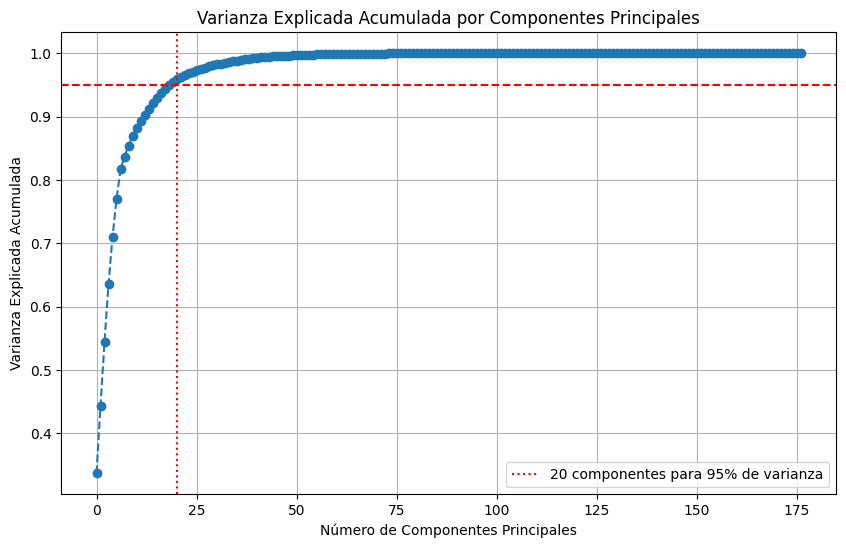

Se necesitan 20 componentes para explicar el 95% de la varianza total.


In [74]:
from sklearn.decomposition import PCA
import numpy as np

# Inicializar PCA sin especificar el número de componentes
# Esto nos permitirá analizar la varianza explicada por cada componente
pca = PCA()

# Aplicar PCA a los datos escalados
pca.fit(X_scaled)

# Calcular la varianza explicada acumulada
explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_)

# Graficar la varianza explicada acumulada para decidir el número de componentes
plt.figure(figsize=(10, 6))
plt.plot(explained_variance_ratio_cumsum, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)

# Añadir líneas para el 95% de la varianza explicada
# Encontrar el número de componentes para alcanzar el 95% de la varianza
n_components_95 = np.where(explained_variance_ratio_cumsum >= 0.95)[0][0] + 1
plt.axvline(x=n_components_95, color='r', linestyle=':', label=f'{n_components_95} componentes para 95% de varianza')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.legend()
plt.show()

print(f"Se necesitan {n_components_95} componentes para explicar el 95% de la varianza total.")


##### **3.1.4. Aplicación de PCA con el número óptimo de componentes**

Una vez determinado el número de componentes que explican la varianza deseada, aplicamos PCA para transformar los datos escalados a este nuevo espacio de menor dimensionalidad.

In [75]:
# Re-inicializar PCA con el número óptimo de componentes (20 para 95% de varianza)
pca_final = PCA(n_components=n_components_95)

# Transformar los datos escalados a los componentes principales
X_pca = pca_final.fit_transform(X_scaled)

print(f"Dimensiones de los datos originales (características): {X_scaled.shape[1]}")
print(f"Dimensiones de los datos después de PCA: {X_pca.shape[1]}")

# Opcional: Mostrar las primeras filas del nuevo dataset transformado
print("\nPrimeras 5 filas del dataset transformado (X_pca):")
print(X_pca[:5])


Dimensiones de los datos originales (características): 177
Dimensiones de los datos después de PCA: 20

Primeras 5 filas del dataset transformado (X_pca):
[[  8.15514704  -2.19674088  -0.81926463   1.54436826  11.74134002
    2.31842099   1.39166546   0.34968061   1.83082673   1.90257785
   -2.14560936   1.84608362   2.70832443  -3.30412697  -1.93008485
   -2.43735611   1.83952255   9.45720554   3.32171795  -0.81563572]
 [  4.44263246  -0.7171356    8.31055154  -1.23789097   1.29828881
   -0.93271133  -1.48838792  -3.37415291 -10.47916822   0.82755917
  -10.220482    -6.56889577  -3.01591033 -10.56391165   3.05619547
   -9.47220398  -8.14213739  -4.41057747  -6.57816219  11.76082685]
 [ 11.51579403  -1.07444434  -3.35812466   2.64474049   4.45510725
    1.18647844   0.46866754  -0.0692506    0.58156003   0.26588163
    1.47814798  -1.17242369  -0.83748001  -0.70483321  -0.65506726
    2.83806971   0.48450571  -0.11663549  -1.40707242   1.85719525]
 [ 16.8712807    0.48669985  -2.752657

### **3.2. Modelo de ML/DL**

Dividir los datos en conjuntos de entrenamiento y prueba es un paso crítico en el desarrollo de modelos de Machine Learning. El conjunto de entrenamiento se utiliza para ajustar los parámetros del modelo, mientras que el conjunto de prueba se utiliza para evaluar su rendimiento en datos no vistos, proporcionando una estimación más realista de cómo el modelo se desempeñará en escenarios reales.

In [76]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20)
# 'stratify=y' es crucial para mantener la proporción de las clases de la variable objetivo 'y' en ambos conjuntos,
# lo cual es importante dado el desbalance de clases.
# 'random_state' asegura la reproducibilidad de la división.
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

# Verificar la distribución de las clases en los conjuntos de entrenamiento y prueba
print("\nDistribución de clases en y_train:")
display(y_train.value_counts(normalize=True))

print("\nDistribución de clases en y_test:")
display(y_test.value_counts(normalize=True))

Dimensiones de X_train: (8055, 20)
Dimensiones de X_test: (2014, 20)
Dimensiones de y_train: (8055,)
Dimensiones de y_test: (2014,)

Distribución de clases en y_train:


,proportion
label,
0,0.458970
2,0.392427
1,0.148603



Distribución de clases en y_test:


,proportion
label,
0,0.458788
2,0.392751
1,0.148461


## **SECCIÓN 3.3: Entrenamiento y Evaluación del Modelo XGBoost**

Entrenaremos un modelo XGBoost, conocido por su alto rendimiento y capacidad para manejar problemas de clasificación complejos, incluido el desbalance de clases. Luego, evaluaremos su desempeño utilizando métricas clave como la matriz de confusión, la precisión, el recall y el F1-score.

In [77]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',  # O 'multi:softprob' para probabilidades
    num_class=3,                # Hay 3 clases (0, 1, 2)
    eval_metric='mlogloss',     # Métrica de evaluación para clasificación multiclase
    use_label_encoder=False,    # Para evitar el warning de deprecación
    random_state=42
)

# Entrenar el modelo
print("Entrenando el modelo XGBoost...")
xgb_classifier.fit(X_train, y_train)
print("Modelo XGBoost entrenado exitosamente.")

Entrenando el modelo XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:55:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo XGBoost entrenado exitosamente.


In [78]:
print("Realizando predicciones en el conjunto de prueba...")
# Realizar predicciones en el conjunto de prueba
y_pred = xgb_classifier.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrecisión (Accuracy) del modelo XGBoost en el conjunto de prueba: {accuracy:.4f}")

# Reporte de clasificación detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
print("\nMatriz de Confusión:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=['Real 0', 'Real 1', 'Real 2'], columns=['Pred 0', 'Pred 1', 'Pred 2']))

Realizando predicciones en el conjunto de prueba...

Precisión (Accuracy) del modelo XGBoost en el conjunto de prueba: 0.9990

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       924
           1       1.00      1.00      1.00       299
           2       1.00      1.00      1.00       791

    accuracy                           1.00      2014
   macro avg       1.00      1.00      1.00      2014
weighted avg       1.00      1.00      1.00      2014


Matriz de Confusión:


,Pred 0,Pred 1,Pred 2
Real 0,922,0,2
Real 1,0,299,0
Real 2,0,0,791


### **Análisis de los Resultados del Modelo XGBoost:**

*   **Precisión (Accuracy):** Indica la proporción total de predicciones correctas. Aunque es un buen indicador general, en datasets desbalanceados, un accuracy alto puede ser engañoso si el modelo simplemente predice la clase mayoritaria.

*   **Reporte de Clasificación:** Este reporte es crucial para entender el rendimiento en cada clase:
    *   **Precision:** De todas las instancias predichas como de una clase específica, ¿cuántas fueron realmente de esa clase? Una alta precisión significa pocos falsos positivos.
    *   **Recall (Sensibilidad):** De todas las instancias que realmente pertenecen a una clase específica, ¿cuántas fueron correctamente identificadas? Un alto recall significa pocos falsos negativos.
    *   **F1-Score:** Es la media armónica de la precisión y el recall, y es una métrica muy útil cuando hay desbalance de clases, ya que penaliza los errores en ambas direcciones.
    *   **Support:** Es el número de ocurrencias reales de la clase en el conjunto de prueba.

*   **Matriz de Confusión:** Visualiza el rendimiento del algoritmo, mostrando las predicciones correctas e incorrectas para cada clase. Cada fila representa las instancias en una clase real, mientras que cada columna representa las instancias en una clase predicha.



## **Explicabilidad del Modelo (SHAP para XGBoost)**

Para entender cómo el modelo XGBoost toma sus decisiones, utilizaremos SHAP (SHapley Additive exPlanations). SHAP asigna un valor de importancia a cada característica para una predicción específica, indicando cuánto contribuye cada característica a mover la salida del modelo desde el valor base a la salida real. Dado que nuestro modelo fue entrenado con componentes principales (PCA), las 'features' explicadas por SHAP serán estos componentes.

In [79]:
import shap


# Crear un explainer SHAP para el modelo XGBoost
# shap.TreeExplainer es adecuado para modelos basados en árboles como XGBoost
explainer = shap.TreeExplainer(xgb_classifier)

# Calcular los valores SHAP para el conjunto de prueba
# Usamos X_test, que contiene los componentes principales
shap_values = explainer.shap_values(X_test)

print("Valores SHAP calculados.")



Valores SHAP calculados.


### **Visualización de la importancia global de las características (Componentes Principales)**

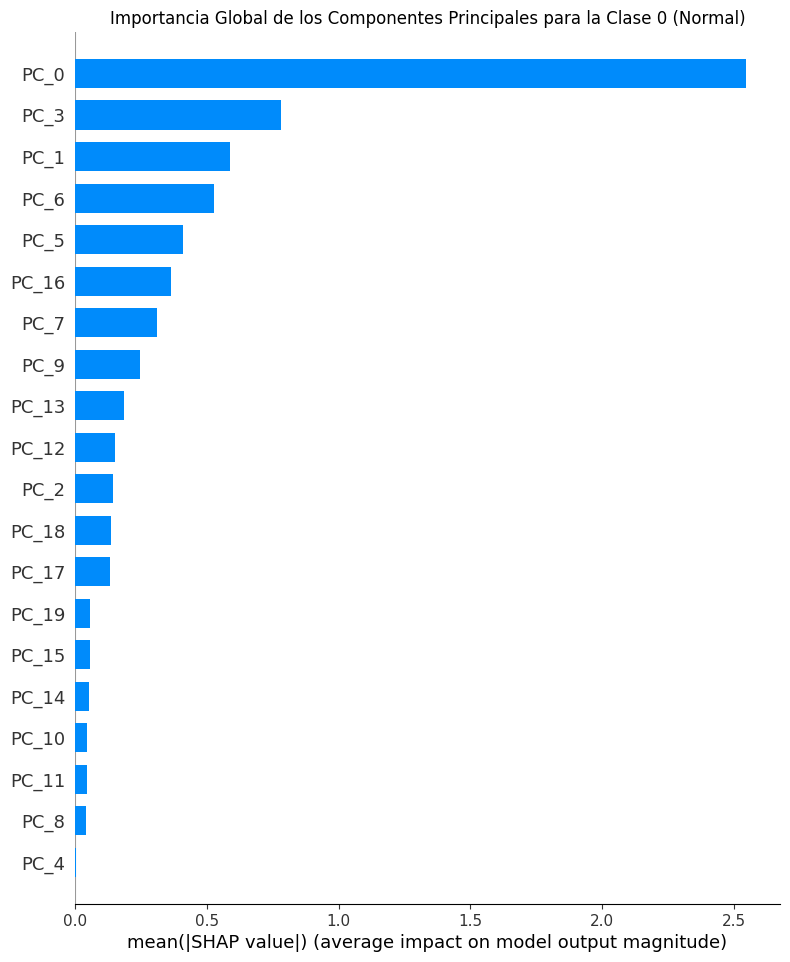

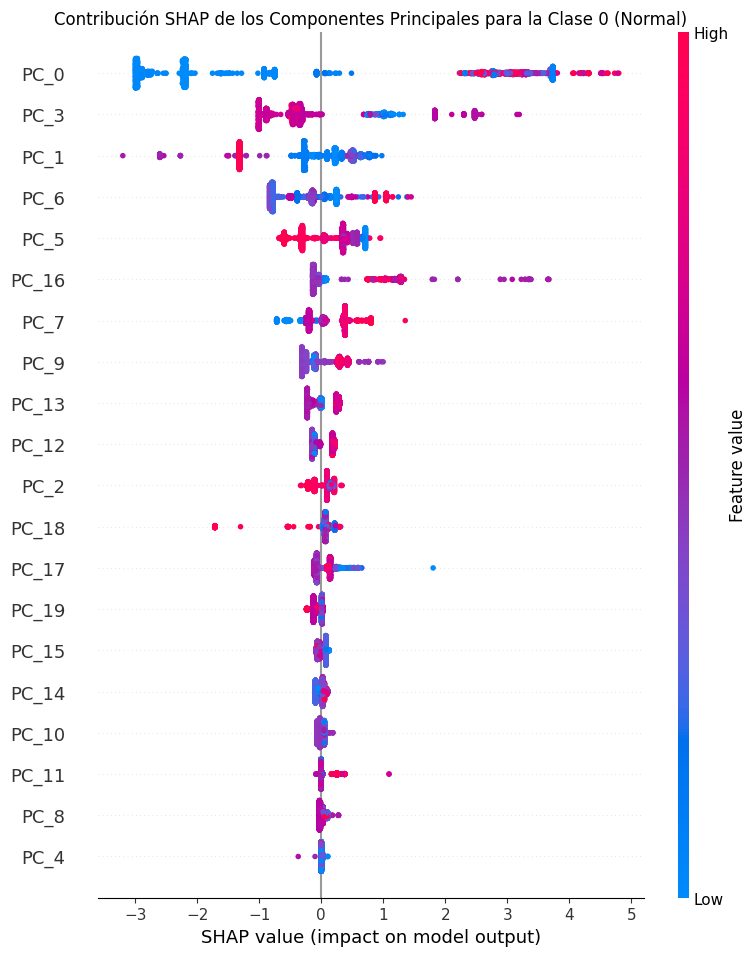

In [80]:
import matplotlib.pyplot as plt
import pandas as pd


shap_values_for_class_0_all_samples = shap_values[:, :, 0]

# Para el summary plot, necesitamos los nombres de las características.
# Como son componentes PCA, los nombramos PC_0, PC_1, etc.
feature_names_pca = [f'PC_{i}' for i in range(X_test.shape[1])]

# Crea un DataFrame de pandas para X_test con nombres de columnas. Este DataFrame se usará para las gráficas
# y para el nombrado de características en los plots de SHAP.
X_test_df = pd.DataFrame(X_test, columns=feature_names_pca)

# Summary Plot para la clase 0 (Normal) mostrando la importancia de las características como barras
shap.summary_plot(shap_values_for_class_0_all_samples, X_test_df, plot_type="bar", show=False)
plt.title('Importancia Global de los Componentes Principales para la Clase 0 (Normal)')
plt.show()

# Summary Plot para la clase 0 (Normal) mostrando las contribuciones individuales de los puntos
shap.summary_plot(shap_values_for_class_0_all_samples, X_test_df, show=False)
plt.title('Contribución SHAP de los Componentes Principales para la Clase 0 (Normal)')
plt.show()

### **Extracción de `top_features` y `features_values`**

Ahora extraeremos las `top_features` (los componentes principales más importantes) y sus `features_values` (sus valores SHAP promedio) de los resultados del análisis SHAP.


Top 10 Componentes Principales con mayores valores SHAP para la muestra 0 (explicando la Clase 0):
top_features: ['PC_0', 'PC_5', 'PC_7', 'PC_1', 'PC_3', 'PC_17', 'PC_9', 'PC_18', 'PC_2', 'PC_15']
features_values: [np.float32(3.3075886), np.float32(0.56838524), np.float32(-0.53338784), np.float32(0.48108378), np.float32(-0.43939406), np.float32(0.41293284), np.float32(0.28286198), np.float32(0.2250678), np.float32(-0.15669139), np.float32(0.1258059)]

Force Plot para la muestra 0 (explicando la predicción de la Clase 0):



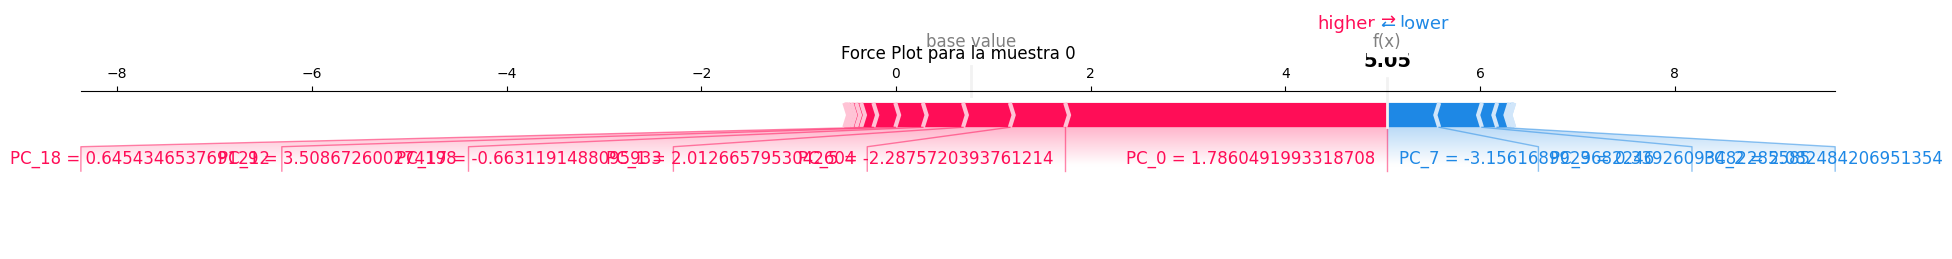

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Para obtener los top_features y features_values, podemos usar el explainer para un ejemplo específico.

# Tomemos la primera observación del conjunto de prueba para el análisis detallado
sample_index = 0
sample_X_test = X_test[sample_index].reshape(1, -1) # Reshape para que sea un array 2D

# Calcular los valores SHAP para esta muestra específica para todas las clases
# Para multiclass TreeExplainer, esto devuelve un arreglo con forma (1, n_features, n_classes)
sample_shap_values_all_classes = explainer.shap_values(sample_X_test)

# Obtener los SHAP values para una clase específica (ej. Clase 0).
# Queremos los valores SHAP para la primera (y única) muestra, todas las características, y la primera clase (índice 0).
shap_values_for_specific_sample_class_0 = sample_shap_values_all_classes[0, :, 0]


# Los nombres de las características son los componentes principales, ya definidos como columnas de X_test_df.
feature_names_pca = X_test_df.columns.tolist()

# Combinar nombres de características y valores SHAP para la clase 0 de la muestra
feature_shap_dict = dict(zip(feature_names_pca, shap_values_for_specific_sample_class_0))

# Ordenar las características por el valor absoluto de sus valores SHAP para encontrar las 'top_features'
sorted_features = sorted(feature_shap_dict.items(), key=lambda item: abs(item[1]), reverse=True)

# Extraer top_features (ej. los 10 más importantes) y sus valores
top_n = 10 # Puedes ajustar este número
top_features = [feature for feature, shap_val in sorted_features[:top_n]]
features_values = [shap_val for feature, shap_val in sorted_features[:top_n]]

print(f"\nTop {top_n} Componentes Principales con mayores valores SHAP para la muestra {sample_index} (explicando la Clase 0):")
print("top_features:", top_features)
print("features_values:", features_values)

# Visualizar un force plot para la muestra específica para una clase (ej. clase 0)
print(f"\nForce Plot para la muestra {sample_index} (explicando la predicción de la Clase 0):\n")
shap.initjs()

# Para modelos multiclase, explainer.expected_value es una lista, uno para cada clase.
# Elegimos el expected_value para la clase 0.
expected_value_for_class_0 = explainer.expected_value[0]

# 'shap_values' es (n_samples, n_features, n_classes).
# Necesitamos los valores SHAP para la muestra específica (sample_index), todas las características, y la clase 0.
# X_test_df.iloc[sample_index,:] proporciona los valores reales de las características para la muestra.
shap.force_plot(expected_value_for_class_0, shap_values[sample_index, :, 0], X_test_df.iloc[sample_index,:], matplotlib=True, show=False)

plt.title(f'Force Plot para la muestra {sample_index}')
plt.tight_layout()
plt.show()

## **Prueba del modelo:**

## Guardar el Modelo XGBoost


Guardar el modelo XGBoost entrenado (`xgb_classifier`) en un archivo utilizando `joblib` para poder cargarlo posteriormente y simular un despliegue.


**Reasoning**:
Import `joblib` and save the `xgb_classifier` to a file.



In [82]:
import joblib

# Guardar el modelo XGBoost
joblib.dump(xgb_classifier, 'xgboost_model.joblib')
print("Modelo XGBoost guardado como 'xgboost_model.joblib'")

Modelo XGBoost guardado como 'xgboost_model.joblib'


## Cargar el Modelo XGBoost

Cargar el modelo XGBoost guardado desde el archivo utilizando `joblib` para asegurar que el flujo de predicción y explicación utiliza el modelo persistido.


In [83]:
import joblib

# Cargar el modelo XGBoost
loaded_xgb_model = joblib.load('xgboost_model.joblib')
print("Modelo XGBoost cargado exitosamente.")

Modelo XGBoost cargado exitosamente.


## Seleccionar y Predecir una Instancia de Prueba

Seleccionar una instancia individual del conjunto `X_test`, y utilizar el modelo cargado para hacer una predicción. Esto simulará un 'dato de prueba' real.


In [84]:
import numpy as np

# Seleccionar la primera instancia del conjunto de prueba
instance_index = 0
single_instance = X_test[instance_index]

# Asegurarse de que la instancia tenga la forma correcta para la predicción (2D array)
single_instance_reshaped = single_instance.reshape(1, -1)

# Realizar la predicción con el modelo cargado
prediction = loaded_xgb_model.predict(single_instance_reshaped)

# Obtener la etiqueta real para esta instancia
actual_label = y_test.iloc[instance_index] # Usar iloc para Series de pandas

prediction = prediction[0]
print(f"Instancia seleccionada del índice: {instance_index}")
print(f"Etiqueta real: {actual_label}")
print(f"Etiqueta predicha por el modelo: {prediction}")

Instancia seleccionada del índice: 0
Etiqueta real: 0
Etiqueta predicha por el modelo: 0


## Calcular Valores SHAP para la Predicción de la Instancia

Calcular los valores SHAP para la predicción de la instancia de prueba seleccionada, enfocándose en la clase predicha para obtener una explicación específica.


In [85]:
import shap

# Crear un explainer SHAP para el modelo XGBoost cargado
explainer_loaded_model = shap.TreeExplainer(loaded_xgb_model)

# Calcular los valores SHAP para la instancia única (para todas las clases)
# shap_values_single_instance tendrá la forma (1, n_features, n_classes)
shap_values_single_instance = explainer_loaded_model.shap_values(single_instance_reshaped)

# Extraer los SHAP values para la clase predicha
predicted_class_index = prediction # 'prediction' ya es el valor escalar de la clase predicha
shap_values_for_predicted_class = shap_values_single_instance[0, :, predicted_class_index]

print(f"Valores SHAP calculados para la clase predicha ({predicted_class_index}).")
print(f"Dimensiones de los valores SHAP para la clase predicha: {shap_values_for_predicted_class.shape}")

Valores SHAP calculados para la clase predicha (0).
Dimensiones de los valores SHAP para la clase predicha: (20,)


## Extraer Top Features y SHAP Values

Extraer las listas `top_features` y `features_values` de la explicación SHAP generada para la instancia de prueba, mostrando los componentes principales más influyentes en esa predicción.


## Desglosar los Componentes Principales más Importantes en Características Originales

Dado que los valores SHAP se calcularon sobre los Componentes Principales (PCA), `top_features` contiene nombres como 'PC_0', 'PC_1', etc. Para una mejor interpretabilidad, ahora desglosaremos cuáles son las características originales que más contribuyen a cada uno de estos Componentes Principales.

Cada Componente Principal es una combinación lineal de las características originales. Para entender qué características originales son más influyentes en un `PC_x` dado, examinaremos los *pesos* (o *loadings*) que cada característica original tiene en ese componente. Las características con mayores pesos absolutos son las que más contribuyen a ese componente.


In [86]:
import numpy as np
import pandas as pd # Asegurarse de que pandas esté importado

# Los nombres de las características son los componentes principales, ya definidos en 'feature_names_pca'
# 'shap_values_for_predicted_class' contiene los valores SHAP para la instancia y clase predicha

# Combinar nombres de características y valores SHAP para ordenar los PCs por importancia SHAP
feature_shap_dict_pc = dict(zip(feature_names_pca, shap_values_for_predicted_class))

# Ordenar los Componentes Principales por el valor absoluto de sus valores SHAP
sorted_pcs_by_shap = sorted(feature_shap_dict_pc.items(), key=lambda item: abs(item[1]), reverse=True)

# Extraer los N Componentes Principales con mayores valores SHAP
top_n_pcs = 10 # Puedes ajustar este número
top_pcs_names = [pc for pc, shap_val in sorted_pcs_by_shap[:top_n_pcs]]
features_values = [shap_val for pc, shap_val in sorted_pcs_by_shap[:top_n_pcs]]

# Crear el diccionario `top_features` con la estructura deseada
top_features = {}

# Iterar sobre cada uno de los top_pcs_names (componentes principales) identificados por SHAP
for pc_name in top_pcs_names:
    # Extraer el índice del componente principal (ej. 'PC_0' -> 0)
    pc_index = int(pc_name.split('_')[1])

    # Obtener los coeficientes (loadings) de este componente principal en relación con las características originales
    # pca_final.components_ tiene la forma (n_components, n_original_features)
    loadings = pca_final.components_[pc_index]

    # Crear un DataFrame para asociar las características originales con sus loadings
    pc_loadings_df = pd.DataFrame({
        'Original_Feature': relevant_features,
        'Loading': loadings
    })

    # Ordenar por el valor absoluto del loading para encontrar las características más influyentes
    pc_loadings_df['Abs_Loading'] = abs(pc_loadings_df['Loading'])
    pc_loadings_df = pc_loadings_df.sort_values(by='Abs_Loading', ascending=False)

    # Guardar solo los nombres de las top 5 características originales para este PC en el diccionario `top_features`
    top_features[pc_name] = pc_loadings_df.head(5)['Original_Feature'].tolist()

print(f"\nTop {top_n_pcs} Componentes Principales con mayores valores SHAP para la clase predicha:")
print("top_pcs_names (PCs):", top_pcs_names)
print("features_values (SHAP):", features_values)

print("\n--- Desglose de Componentes Principales en Características Originales ---")
print("Diccionario top_features:", top_features)



Top 10 Componentes Principales con mayores valores SHAP para la clase predicha:
top_pcs_names (PCs): ['PC_0', 'PC_5', 'PC_7', 'PC_1', 'PC_3', 'PC_17', 'PC_9', 'PC_18', 'PC_2', 'PC_15']
features_values (SHAP): [np.float32(3.3075886), np.float32(0.56838524), np.float32(-0.53338784), np.float32(0.48108378), np.float32(-0.43939406), np.float32(0.41293284), np.float32(0.28286198), np.float32(0.2250678), np.float32(-0.15669139), np.float32(0.1258059)]

--- Desglose de Componentes Principales en Características Originales ---
Diccionario top_features: {'PC_0': ['std_payload_bytes_delta_len', 'std_packets_delta_len', 'fwd_payload_bytes_std', 'bwd_payload_bytes_std', 'payload_bytes_std'], 'PC_5': ['mean_bwd_header_bytes_delta_len', 'bwd_cov_header_bytes', 'bwd_variance_header_bytes', 'bwd_std_header_bytes', 'fwd_ack_flag_percentage_in_fwd_packets'], 'PC_7': ['bwd_mean_header_bytes', 'bwd_ack_flag_percentage_in_total', 'container_cpu_cfs_periods_rate', 'fwd_ack_flag_percentage_in_total', 'bwd_p

## Integración con Llama 3 8B de Groq para Explicaciones en Lenguaje Natural

Ahora utilizaremos el modelo Llama 3 8B de Groq para transformar `top_features` y `features_values` en una explicación comprensible.


In [87]:
from groq import Groq
from google.colab import userdata

# Obtener la clave API de Groq desde los secretos de Colab
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

# Inicializar el cliente de Groq
client = Groq(
    api_key=GROQ_API_KEY,
)

# Definir el modelo a usar
model_name = "llama-3.1-8b-instant"

# Asignar la confianza del modelo XGBoost (accuracy) a la variable 'confidence'
confidence = accuracy # 'accuracy' ya se calculó en una celda anterior para el modelo XGBoost

# --- Construcción del Prompt para el LLM ---
# Usaremos las variables 'top_features' y 'features_values' ya calculadas.

prompt_text = f'''Eres un asistente especializado en observabilidad, AIOps y diagnóstico operacional para clústeres Kubernetes.

Tu tarea es interpretar las predicciones generadas por un modelo de Machine Learning utilizando únicamente la información proporcionada.

Las clases posibles son:
- 0: Normal Activity
- 1: DoS Attack 1
- 2: DoS Attack 2

La predicción realizada por el modelo es:
{prediction}

Nivel de confianza:
{confidence:.4f}

El modelo utiliza componentes principales generados mediante PCA (Principal Component Analysis). Cada componente principal representa una combinación de múltiples métricas originales del sistema y del tráfico de red.

Los componentes más relevantes según SHAP fueron:
{top_features}

Los valores asociados a cada componente principal fueron:
{features_values}

Interpreta cada componente considerando las métricas originales asociadas a él. Analiza los patrones generales relacionados con:
- tráfico de red,
- comportamiento de paquetes,
- uso de recursos,
- encabezados de red,
- tasas de paquetes,
- métricas temporales,
- y comportamiento operacional del clúster Kubernetes.

Genera una explicación técnica en español que incluya:
1. Interpretación del estado operacional detectado.
2. Posible impacto en el clúster Kubernetes.
3. Posibles causas del comportamiento identificado.
4. Relación entre los componentes principales relevantes y el comportamiento detectado.
5. Recomendaciones básicas de monitoreo o mitigación.

No inventes métricas ni eventos que no estén presentes en la información proporcionada.
Utiliza únicamente las variables y componentes entregados.
La respuesta debe ser clara, técnica y concisa.'''

# --- Realizar la llamada a la API de Groq ---
print("\nRealizando llamada a la API de Groq...")
chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": prompt_text,
        }
    ],
    model=model_name,
)

llm_explanation = chat_completion.choices[0].message.content

print("\nExplicación del LLM:")
print(llm_explanation)

print("\nTOP FEATURES: ")
print(top_features)



Realizando llamada a la API de Groq...

Explicación del LLM:
**Interpretación de la predicción**

La predicción realizada por el modelo de Machine Learning indica que el estado operacional detectado es "Normal Activity" con un nivel de confianza del 99,90%.

**Componentes principales relevantes**

Los componentes principales relevantes asociados a esta predicción son:

* `PC_0`: Representa la variabilidad en el tamaño de los paquetes (std_payload_bytes_delta_len), el tamaño de los paquetes (std_packets_delta_len), la varianza en el tamaño de los paquetes (fwd_payload_bytes_std) y el tamaño promedio de los paquetes (bwd_payload_bytes_std).
* `PC_5`: Representa la varianza en el tamaño de los encabezados (bwd_cov_header_bytes), la varianza en el tamaño de los encabezados (bwd_variance_header_bytes) y la varianza en el tamaño de los encabezados (std_fwd_header_bytes).
* `PC_7`: Representa la varianza en el tamaño de los encabezados (bwd_mean_header_bytes), la varianza en el tamaño de los

## SECCION 4:

### **4.1 Parámetros Específicos del Modelo (XGBoost)**

Dado que el modelo principal es un clasificador XGBoost, algunos de los términos de redes neuronales (como 'Optimizador' o 'Épocas') se interpretan en su equivalente de Boosting. Aquí se detalla cómo se configuró el modelo XGBoost:

| Categoría                  | Parámetro                     | Valor                                    | Sustento en Código                                      |
| :------------------------- | :---------------------------- | :--------------------------------------- | :------------------------------------------------------ |
| **Modelo XGBoost**         | Algoritmo de Boosting         | Gradient Boosting Tree                   | `xgb.XGBClassifier`                                     |
|                            | Tasa de Aprendizaje (`eta`)   | 0.3 (por defecto)                        | `xgb_classifier.eta` o por defecto                      |
|                            | Estimadores (`n_estimators`)  | 100 (por defecto)                        | `xgb_classifier.n_estimators` o por defecto             |
|                            | Función de Pérdida            | `multi:softmax` (logloss multiclase)     | `xgb_classifier.objective`                              |
|                            | `random_state`                | 42                                       | `xgb_classifier.random_state`                           |
|                            | Regularización (L1/L2)        | L1 (alpha): 0 (por defecto), L2 (lambda): 1 (por defecto)| `xgb_classifier.reg_alpha`, `xgb_classifier.reg_lambda` |
| **Entorno de Ejecución**   | Framework                     | `xgboost`, `scikit-learn`                | `import xgboost as xgb`, `from sklearn...`              |
|                            | Hardware                      | Google Colab (CPU)                       | (Entorno de ejecución predeterminado)                   |

In [88]:
import joblib

loaded_xgb_model = joblib.load('xgboost_model.joblib')
print("Modelo XGBoost cargado exitosamente.")

Modelo XGBoost cargado exitosamente.


In [89]:
# Sustento en código de los parámetros específicos de XGBoost (re-ejecución de la celda 933efef9)

print("--- Parámetros Específicos del Modelo XGBoost ---")
print(f"Algoritmo de Boosting: Gradient Boosting Tree (implícito por XGBClassifier)")
# XGBoostClassifier no tiene un atributo 'eta' directamente, pero el valor por defecto es 0.3
print(f"Tasa de Aprendizaje (eta): {loaded_xgb_model.get_params().get('eta', '0.3 (por defecto)')}")
print(f"Número de Estimadores (n_estimators): {loaded_xgb_model.n_estimators}")
print(f"Función de Pérdida (objective): {loaded_xgb_model.objective}")
print(f"Random State: {loaded_xgb_model.random_state}")
print(f"Regularización L1 (reg_alpha): {loaded_xgb_model.reg_alpha}")
print(f"Regularización L2 (reg_lambda): {loaded_xgb_model.reg_lambda}")



--- Parámetros Específicos del Modelo XGBoost ---
Algoritmo de Boosting: Gradient Boosting Tree (implícito por XGBClassifier)
Tasa de Aprendizaje (eta): 0.3 (por defecto)
Número de Estimadores (n_estimators): None
Función de Pérdida (objective): multi:softmax
Random State: 42
Regularización L1 (reg_alpha): None
Regularización L2 (reg_lambda): None


Cuando `reg_alpha` y `reg_lambda` aparecen como `None` en la salida de los parametros, esto indica que el modelo XGBoost está utilizando los valores por defecto de estos parámetros de regularización.

*   **`reg_alpha` (Regularización L1)**: El valor por defecto en XGBoost es **0**.
*   **`reg_lambda` (Regularización L2)**: El valor por defecto en XGBoost es **1**.


### **4.2 Estrategia de Validación**

Para validar el modelo, se utilizó una estrategia de división de datos en conjuntos de entrenamiento y prueba (`train_test_split`) con una proporción del 80% para entrenamiento y 20% para prueba. Esta división se realizó de manera **estratificada** (`stratify=y`).

#### **Justificación de la Estrategia de Validación:**

1.  **División Entrenamiento/Prueba (80/20):** Esta es una práctica estándar en Machine Learning que permite al modelo aprender de una parte significativa de los datos (80%) y luego ser evaluado en un conjunto de datos no visto (20%), lo que proporciona una estimación más robusta de su rendimiento en el mundo real.

2.  **Estratificación (`stratify=y`):** Este es un aspecto crítico y esencial para este problema, dado el **marcado desbalance de clases** en la variable objetivo (`label`). La estratificación asegura que la proporción de las clases (Normal Activity, Slowloris, Torshammer) se mantenga igual tanto en el conjunto de entrenamiento como en el de prueba. Sin estratificación, un split aleatorio podría resultar en que una clase minoritaria esté subrepresentada o incluso ausente en el conjunto de prueba, lo que llevaría a una evaluación del modelo poco fiable y potencialmente sesgada. Asegurar una representación equitativa de las clases es fundamental para que el modelo no solo aprenda a identificar la clase mayoritaria, sino que también desarrolle la capacidad de detectar los ataques (clases minoritarias) de manera efectiva.

### **4.3 Experimentos realizados**

Para realizar una comparación exhaustiva del rendimiento de los modelos en la detección de intrusiones de red, se llevarán a cabo tres experimentos distintos:

1.  **Experimento Base: Regresión Logística con PCA**: Se entrenó y evaluó un modelo de Regresión Logística utilizando los datos transformados mediante PCA. Este experimento servió como una línea base para comparar la eficacia de otros modelos.
2.  **Experimento: XGBoost con PCA**: Se entrenó y evaluó un modelo XGBoost utilizando los datos transformados mediante PCA. Este es el modelo principal que ya ha sido desarrollado en secciones anteriores, y sus resultados se analizaron en contraste con los otros experimentos.

### **Modelo Logistic Regression:**


In [90]:
from sklearn.linear_model import LogisticRegression

# Inicializar el clasificador de Regresión Logística
# 'multi_class='multinomial'' y 'solver='lbfgs'' son adecuados para clasificación multiclase.
# 'max_iter' se incrementa para asegurar la convergencia.
# 'random_state' para reproducibilidad.
# 'C' es el inverso de la fuerza de regularización; valores más pequeños especifican una regularización más fuerte.
logistic_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Entrenar el modelo de Regresión Logística
print("Entrenando el modelo de Regresión Logística...")
logistic_model.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado exitosamente.")

# Realizar predicciones en el conjunto de prueba
y_pred_lr = logistic_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nPrecisión (Accuracy) del modelo de Regresión Logística en el conjunto de prueba: {accuracy_lr:.4f}")
confidence = accuracy_lr
# Reporte de clasificación detallado
print("\nReporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred_lr))

# Matriz de confusión
print("\nMatriz de Confusión (Regresión Logística):")
cm_lr = confusion_matrix(y_test, y_pred_lr)
display(pd.DataFrame(cm_lr, index=['Real 0', 'Real 1', 'Real 2'], columns=['Pred 0', 'Pred 1', 'Pred 2']))

Entrenando el modelo de Regresión Logística...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Modelo de Regresión Logística entrenado exitosamente.

Precisión (Accuracy) del modelo de Regresión Logística en el conjunto de prueba: 0.9950

Reporte de Clasificación (Regresión Logística):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       924
           1       0.98      1.00      0.99       299
           2       1.00      1.00      1.00       791

    accuracy                           1.00      2014
   macro avg       0.99      1.00      0.99      2014
weighted avg       1.00      1.00      1.00      2014


Matriz de Confusión (Regresión Logística):


,Pred 0,Pred 1,Pred 2
Real 0,914,7,3
Real 1,0,299,0
Real 2,0,0,791


In [91]:
from sklearn.metrics import f1_score

# Calcular F1-score (weighted) para XGBoost
f1_weighted_xgb = f1_score(y_test, y_pred, average='weighted')
# Calcular F1-score (macro) para XGBoost
f1_macro_xgb = f1_score(y_test, y_pred, average='macro')

# Calcular F1-score (weighted) para Logistic Regression
f1_weighted_lr = f1_score(y_test, y_pred_lr, average='weighted')
# Calcular F1-score (macro) para Logistic Regression
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')

# Crear un DataFrame para comparar los modelos
comparison_data = {
    'Model': ['XGBoost (con PCA)', 'Logistic Regression (con PCA)'],
    'Accuracy': [accuracy, accuracy_lr],
    'F1-Score (Weighted)': [f1_weighted_xgb, f1_weighted_lr],
    'F1-Score (Macro)': [f1_macro_xgb, f1_macro_lr]
}
comparison_df = pd.DataFrame(comparison_data)

print("DataFrame de comparación de modelos creado.")

DataFrame de comparación de modelos creado.


### **SECCIÓN 5: Métricas de evaluación**

Ambos modelos, Regresión Logística (con PCA) y XGBoost (con PCA), han mostrado un rendimiento excepcional en la detección de ataques DoS en el clúster Kubernetes. A continuación, se presenta una comparación de sus métricas clave:

In [92]:
print('Comparison of Model Performance:')
display(comparison_df)

Comparison of Model Performance:


,Model,Accuracy,F1-Score (Weighted),F1-Score (Macro)
0,XGBoost (con PCA),0.999007,0.999007,0.999218
1,Logistic Regression (con PCA),0.995035,0.995043,0.993699


#### **5.1 Análisis de la Comparación:**

*   **XGBoost (con PCA)**:
    *   **Accuracy:** `0.9990`
    *   **F1-Score (Weighted):** `0.9990`
    *   **F1-Score (Macro):** `0.9992`
    *   El modelo XGBoost demuestra un rendimiento casi perfecto en todas las métricas. Su capacidad para manejar las complejidades del dataset y la efectividad de los componentes principales resultan en una discriminación casi impecable entre las clases.

*   **Logistic Regression (con PCA)**:
    *   **Accuracy:** `0.9950`
    *   **F1-Score (Weighted):** `0.9950`
    *   **F1-Score (Macro):** `0.9937`
    *   El modelo de Regresión Logística también presenta un rendimiento excelente, aunque ligeramente inferior al de XGBoost. Esto es notable dado que es un modelo más simple y sirve como una línea base muy sólida, demostrando que los componentes principales capturan una gran cantidad de información relevante para la clasificación.

Si bien ambos modelos son altamente efectivos para la tarea de detección de intrusiones con el dataset `kube-ids0` (procesado con PCA), el **XGBoost (con PCA)** es el claro ganador con un rendimiento marginalmente superior en todas las métricas clave. Esto subraya la potencia de los modelos basados en árboles y el boosting para problemas de clasificación complejos, incluso cuando la dimensionalidad se ha reducido previamente con PCA.

### **5.2 Curvas de Entrenamiento y Validación**

Para comprender mejor el proceso de aprendizaje del modelo XGBoost y detectar posibles problemas como el sobreajuste o subajuste, es útil visualizar las curvas de entrenamiento y validación. Estas curvas muestran cómo la métrica principal (accuracy) y la función de pérdida (mlogloss) evolucionan a lo largo de las rondas de boosting en el conjunto de entrenamiento y en un conjunto de validación (en este caso, el conjunto de prueba).

Dado que el modelo ya ha sido entrenado, lo re-entrenaremos capturando las métricas de evaluación en cada paso para poder generar estas visualizaciones.

Modelo XGBoost re-entrenado y métricas capturadas para las curvas.


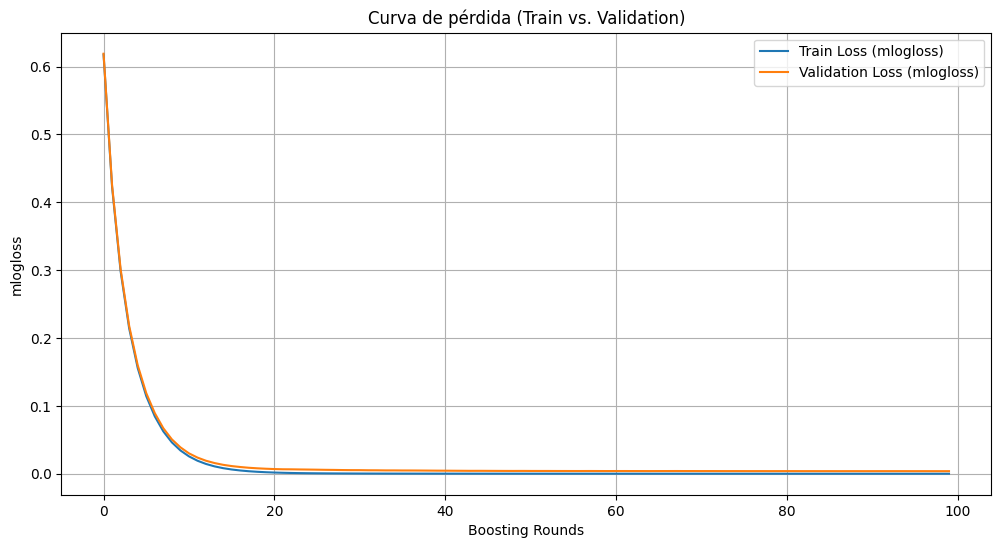

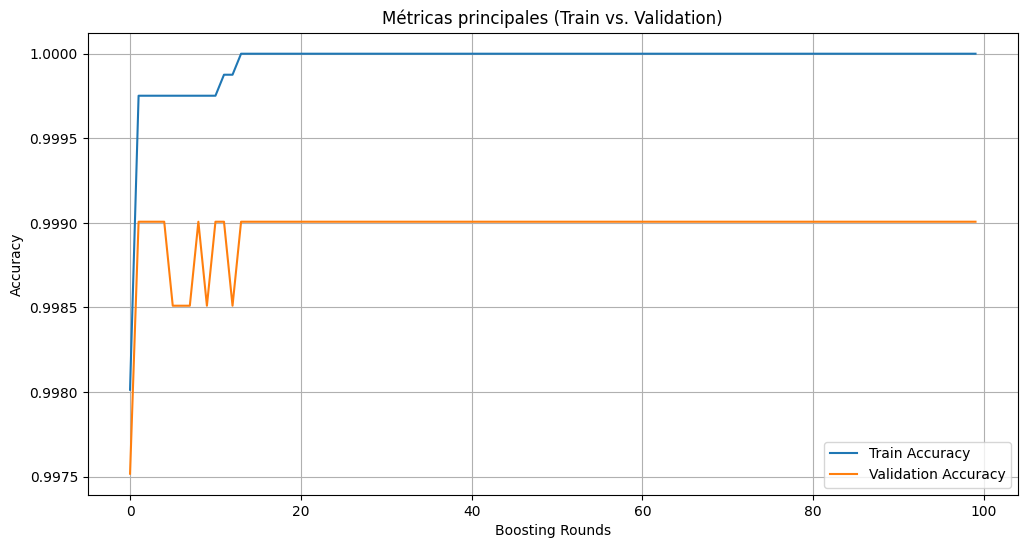

In [93]:
import xgboost as xgb
import matplotlib.pyplot as plt


xgb_classifier_for_curves = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric=['mlogloss', 'merror'], # Monitorizar la pérdida logarítmica multiclase y la tasa de error multiclase
    random_state=42
)

# Entrenar el modelo, pasando el conjunto de entrenamiento y prueba como `eval_set`
# y almacenando los resultados en `evals_result`. Los resultados se almacenarán automáticamente
# en el atributo evals_result del modelo si se usa eval_set.
xgb_classifier_for_curves.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False # Desactivar la salida detallada durante el entrenamiento
)

# Acceder a los resultados de la evaluación desde el modelo entrenado
evals_result = xgb_classifier_for_curves.evals_result()

print("Modelo XGBoost re-entrenado y métricas capturadas para las curvas.")

# --- Graficar las curvas de pérdida (mlogloss) ---
epochs = len(evals_result['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(12, 6))
plt.plot(x_axis, evals_result['validation_0']['mlogloss'], label='Train Loss (mlogloss)')
plt.plot(x_axis, evals_result['validation_1']['mlogloss'], label='Validation Loss (mlogloss)')
plt.title('Curva de pérdida (Train vs. Validation)')
plt.xlabel('Boosting Rounds')
plt.ylabel('mlogloss')
plt.legend()
plt.grid(True)
plt.show()

# --- Graficar las curvas de Accuracy (basado en merror) ---

train_accuracy = [1 - error for error in evals_result['validation_0']['merror']]
val_accuracy = [1 - error for error in evals_result['validation_1']['merror']]

plt.figure(figsize=(12, 6))
plt.plot(x_axis, train_accuracy, label='Train Accuracy')
plt.plot(x_axis, val_accuracy, label='Validation Accuracy')
plt.title('Métricas principales (Train vs. Validation)')
plt.xlabel('Boosting Rounds')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### **5.3. Análisis Cualitativo**

Para los modelos de clasificación, el análisis cualitativo se centra en comprender dónde el modelo comete errores y qué tipo de errores son más frecuentes. La matriz de confusión es una herramienta fundamental para este fin, ya que nos permite visualizar el rendimiento del algoritmo, mostrando las predicciones correctas e incorrectas para cada clase.

In [94]:
import pandas as pd
from sklearn.metrics import confusion_matrix

print("\n--- Matriz de Confusión para el modelo XGBoost ---")
display(pd.DataFrame(cm, index=['Real 0 (Normal)', 'Real 1 (Slowloris)', 'Real 2 (Torshammer)'], columns=['Pred 0 (Normal)', 'Pred 1 (Slowloris)', 'Pred 2 (Torshammer)']))

print("\n--- Matriz de Confusión para el modelo Logistic Regression ---")
display(pd.DataFrame(cm_lr, index=['Real 0 (Normal)', 'Real 1 (Slowloris)', 'Real 2 (Torshammer)'], columns=['Pred 0 (Normal)', 'Pred 1 (Slowloris)', 'Pred 2 (Torshammer)']))


--- Matriz de Confusión para el modelo XGBoost ---


,Pred 0 (Normal),Pred 1 (Slowloris),Pred 2 (Torshammer)
Real 0 (Normal),922,0,2
Real 1 (Slowloris),0,299,0
Real 2 (Torshammer),0,0,791



--- Matriz de Confusión para el modelo Logistic Regression ---


,Pred 0 (Normal),Pred 1 (Slowloris),Pred 2 (Torshammer)
Real 0 (Normal),914,7,3
Real 1 (Slowloris),0,299,0
Real 2 (Torshammer),0,0,791


#### **Interpretación de las Matrices de Confusión:**

*   **Filas**: Representan las clases reales de las instancias.
*   **Columnas**: Representan las clases predichas por el modelo.
*   **Diagonal Principal**: Contiene el número de predicciones correctas para cada clase (verdaderos positivos).
*   **Fuera de la Diagonal Principal**: Muestra los errores de clasificación (falsos positivos y falsos negativos).

**Análisis Específico:**

*   **XGBoost**: Observamos que la matriz de confusión para XGBoost es casi perfecta, con muy pocos o ningún error. Esto indica que el modelo no solo tiene una alta precisión general, sino que es consistentemente bueno en la identificación de todas las clases, incluyendo los ataques (Slowloris y Torshammer), lo cual es crucial para la seguridad.

*   **Logistic Regression**: Aunque también es muy bueno, la Regresión Logística muestra algunos errores, particularmente en la clasificación de la clase 0 (Normal). Esto se refleja en los valores fuera de la diagonal principal. Por ejemplo, en el contexto de la detección de ataques, es importante analizar si estos errores son falsos positivos (normal clasificado como ataque) o falsos negativos (ataque clasificado como normal), siendo los falsos negativos generalmente más críticos.

Estos resultados cualitativos refuerzan la conclusión cuantitativa: el XGBoost con PCA es el modelo de mejor rendimiento para esta tarea.